<a href="https://colab.research.google.com/github/rajeshxdatascience/Car-Price-Prediction-ML/blob/main/02_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np


In [3]:
df = pd.read_parquet("/content/car_price_prediction.parquet")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3550 entries, 0 to 3549
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   km_driven                   3550 non-null   float64
 1   car_age                     3550 non-null   int64  
 2   log_price                   3550 non-null   float64
 3   brand_bmw                   3550 non-null   bool   
 4   brand_chevrolet             3550 non-null   bool   
 5   brand_datsun                3550 non-null   bool   
 6   brand_fiat                  3550 non-null   bool   
 7   brand_ford                  3550 non-null   bool   
 8   brand_honda                 3550 non-null   bool   
 9   brand_hyundai               3550 non-null   bool   
 10  brand_mahindra              3550 non-null   bool   
 11  brand_maruti                3550 non-null   bool   
 12  brand_mercedes-benz         3550 non-null   bool   
 13  brand_nissan                3550 

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [6]:
X = df.drop('log_price',axis=1)
y = df['log_price']

X_train, X_test , y_train, y_test = train_test_split(X, y , test_size=0.2,random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [7]:
y_pred = lr.predict(X_test)

In [23]:
print("MAE", mean_absolute_error(y_test,y_pred))
print("MSE", mean_squared_error(y_test,y_pred))
print("R2 Score", r2_score(y_test,y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test,y_pred)))

MAE 0.30584805786819597
MSE 0.14798027049277065
R2 Score 0.7840409786174871
RMSE 0.38468203817278845


In [14]:
lr.coef_

array([-1.14429635e-06, -1.10126713e-01, -9.21715484e-02, -1.42203183e+00,
       -1.47240001e+00, -1.39699245e+00, -1.08386677e+00, -8.58860637e-01,
       -1.06161139e+00, -9.05299455e-01, -1.17546534e+00,  1.79677718e-01,
       -1.10999885e+00, -2.69780263e-01, -1.22541903e+00, -9.61028865e-01,
       -1.55627827e+00, -4.84598617e-01, -1.01224239e+00, -1.29552758e-01,
       -4.85570713e-02, -1.33309100e-01, -1.00093353e-01, -4.27962297e-01,
       -5.07472682e-01, -4.31770123e-01])

In [15]:
lr.intercept_

np.float64(16.03629943305918)

Text(0.5, 1.0, 'Actual vs Predicted')

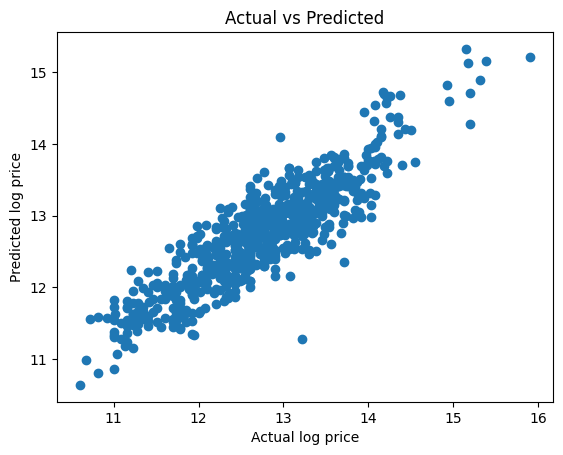

In [16]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual log price")
plt.ylabel("Predicted log price")
plt.title("Actual vs Predicted")

In [18]:
X_test.shape

(710, 26)

In [21]:
r2 = r2_score(y_test,y_pred)


In [24]:
print("Adjusted R2 Score",1 - ((1 - r2)*(710-1))/(710-1-26))

Adjusted R2 Score 0.7758199909806711


Text(0, 0.5, 'Residuals')

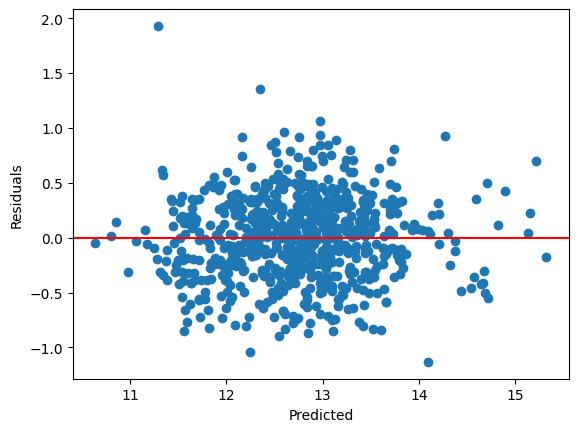

In [25]:
plt.scatter(y_pred, y_test - y_pred)
plt.axhline(0,color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")